# 01 Trump Truth Social Tweets: Data Cleaning & Feature Engineering
---
This notebook covers data collection, exploration and cleaning for the Trump Truth Social dataset. End result is an concatenated dataset with all unique tweets within the explored time period and a number of (potentially) relevant features for our further analysis and modelling.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from bs4 import BeautifulSoup

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DATA_DIR = Path('.')
OUT_DIR  = Path('../data')
OUT_DIR.mkdir(exist_ok=True)

---
## 1. Data Loading

The raw data is initially split across three JSON files, obtained from Truth Social using a web scraper. Each record is one post. The files have temporal overlap, so we start with a deduplication on the unique post `id`.

In [2]:
files = [
    DATA_DIR / 'realDonaldTrump_truths.json',
    DATA_DIR / 'realDonaldTrump_truths_2.json',
    DATA_DIR / 'realDonaldTrump_truths_3.json',
]

frames = []
for f in files:
    chunk = pd.read_json(f, lines=True)
    chunk['_source_file'] = f.name
    frames.append(chunk)

raw = pd.concat(frames, ignore_index=True)
raw['created_at'] = pd.to_datetime(raw['created_at'], utc=True)

n_raw = len(raw)

# Keep the most recently scraped copy so engagement counts are freshest
df = raw.sort_values('_pulled').drop_duplicates(subset='id', keep='last').reset_index(drop=True)

print(f'Raw rows across all files : {n_raw:,}')
print(f'Duplicate rows removed    : {n_raw - len(df):,}')
print(f'Unique posts              : {len(df):,}')
print(f'Date range                : {df["created_at"].min().date()} -> {df["created_at"].max().date()}')
print(f'Columns                   : {len(df.columns)}')

Raw rows across all files : 7,120
Duplicate rows removed    : 4,207
Unique posts              : 2,913
Date range                : 2025-11-14 -> 2026-04-10
Columns                   : 42


**What we found:** After deduplication we have **2,913 unique posts** spanning five months (November 2025 to April 2026). The three scrape batches overlapped significantly — 4,207 rows were duplicate copies of the same posts scraped at different times. We only keep one copy per unique post id.

---
## 2. Brief Raw Data Exploration

Before cleaning anything, we look at the raw deduplicated dataset to understand what columns are available, how dense information is, which are worth keeping, and what the key distributions look like.

In [3]:
def safe_nunique(s):
    try:
        return s.nunique()
    except TypeError:
        return 'nested'

col_audit = pd.DataFrame({
    'dtype'   : df.dtypes.astype(str),
    'non_null': df.notna().sum(),
    'null_pct': (df.isna().sum() / len(df) * 100).round(1),
    'n_unique': {c: safe_nunique(df[c]) for c in df.columns},
})
col_audit

,dtype,non_null,null_pct,n_unique
id,int64,2913,0.0,2913
created_at,"datetime64[ns, UTC]",2913,0.0,2913
in_reply_to_id,float64,0,100.0,0
quote_id,float64,453,84.4,449
in_reply_to_account_id,float64,0,100.0,0
sensitive,bool,2913,0.0,1
spoiler_text,object,2913,0.0,1
visibility,object,2913,0.0,1
language,object,1381,52.6,17
uri,object,2913,0.0,2913


**Column observations:**
- **Eight columns are 100% null** (`in_reply_to_id`, `in_reply_to_account_id`, `group`, `in_reply_to`, `reaction`, `poll`, `edited_at`, `title`) — These features don't contain any info and will be dropped.
- **`language`** is missing for ~53% of posts. Missing here means the web scraper did not auto-detect a language — not that the post has no text.
- **`card`** (link preview) is present for only ~16% of posts — most posts are plain text with no external link.
- **`reblog`** is non-null for ~4% of posts — these are ReTruths (reshares of accounts' content) with no original Trump-written text.
- Several boolean columns (`favourited`, `reblogged`, `muted`, etc.) are always `False` and hence, carry no information usable for our model.

### Plot 1: Daily posting volume

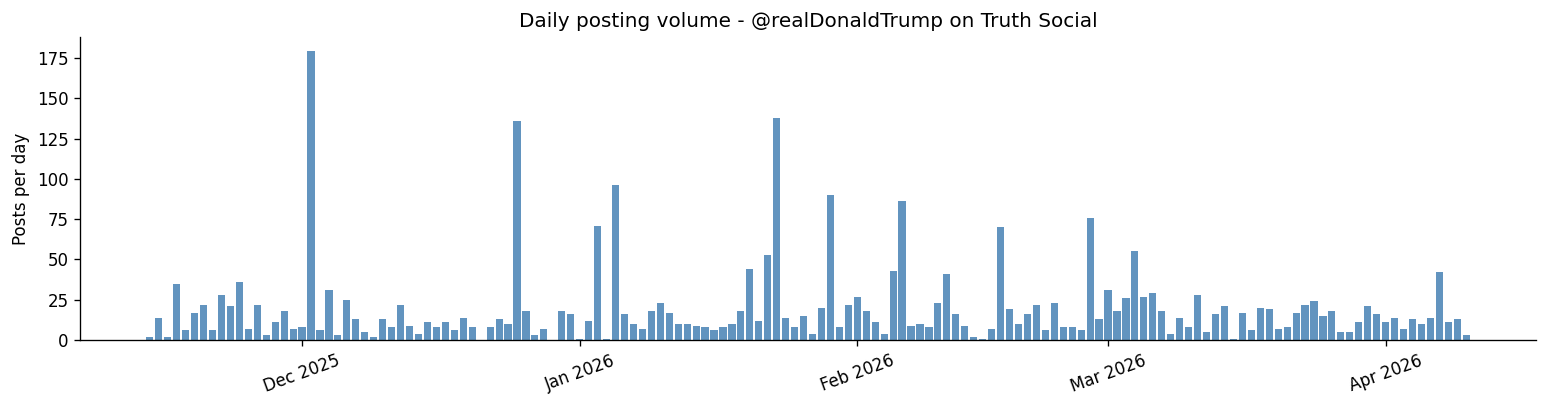

Top 5 most active days:
      date  posts
2025-12-02    179
2026-01-23    138
2025-12-25    136
2026-01-05     96
2026-01-29     90


In [4]:
daily_raw = df.set_index('created_at').resample('D').size()

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.bar(daily_raw.index, daily_raw.values, width=0.8, color='steelblue', alpha=0.85)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_title('Daily posting volume - @realDonaldTrump on Truth Social', fontsize=12)
ax.set_ylabel('Posts per day')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

top5 = daily_raw.nlargest(5).reset_index()
top5.columns = ['date', 'posts']
top5['date'] = top5['date'].dt.date
print('Top 5 most active days:')
print(top5.to_string(index=False))

**Observation:** Posting volume is varying a lot. Most days we see 5-30 posts, but there are some clear spikes, exceeding 50 posts per day, and it will be interesting to explore if they coincide with breaking (geo)political events covered in news media. These spikes in posting volume can be used as direct signals of increased political activity from Trump, and it is our hypothesis that such spikes correlate with movements in the economic, social and financial variables we will study and try to predict.

### Plot 2: Distribution of upvotes (likes)

On Truth Social, an **upvote** (called a "favourite") is the equivalent of a Twitter/X like. They are the most direct measure of audience approval available in the data. For example, a post with 50,000 upvotes shows far more visible support than one with 500, and tracking how upvote levels evolve over time can give us an indication of the resilience of Trump's popularity. In other words, does his base stay engaged during political crises, economic shocks, or controversial decisions? 

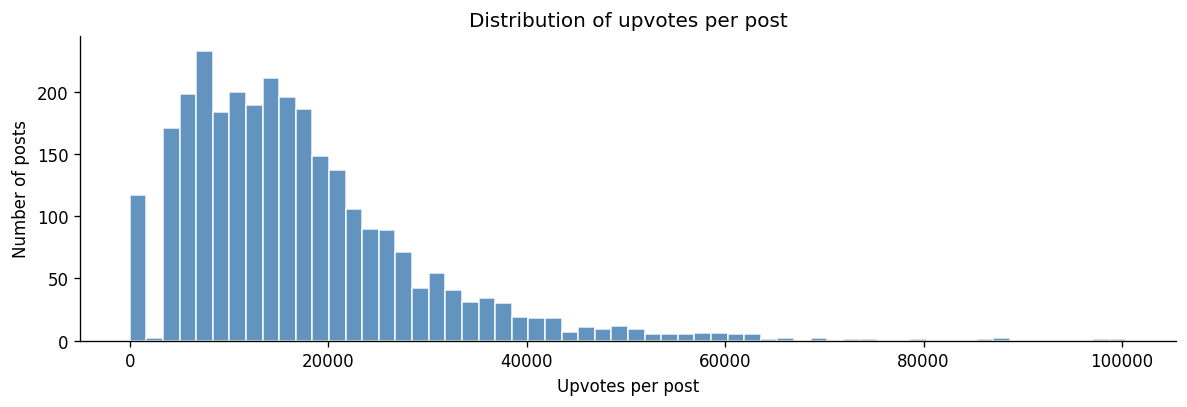

count      2913.0
mean      16886.0
std       11862.0
min           0.0
25%        8429.0
50%       14658.0
75%       21977.0
max      100415.0


In [5]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(df['favourites_count'], bins=60, color='steelblue', alpha=0.85, edgecolor='white')
ax.set_title('Distribution of upvotes per post')
ax.set_xlabel('Upvotes per post')
ax.set_ylabel('Number of posts')
plt.tight_layout()
plt.show()

print(df['favourites_count'].describe().round(0).to_string())

**Observation:** Most posts receive a moderate number of upvotes (median is 14658), but a small number of posts receive signicifanctly more upvptes (some exceeding 100,000). This means the distribution has a long right tail, i.e. a handful of posts are massively more popular than the average. Those outlier posts are most likely tied to big political moments/news and are worth paying attention to when we later analyse specific events and tie the Trump data to news data.

### Plot 3: Post type breakdown

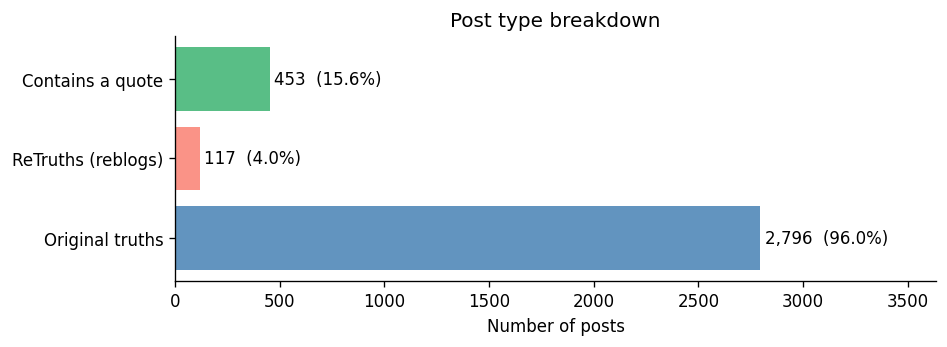

In [6]:
n_reblogs  = df['reblog'].notna().sum()
n_quotes   = df['quote_id'].notna().sum()
n_original = len(df) - n_reblogs

labels = ['Original truths', 'ReTruths (reblogs)', 'Contains a quote']
counts = [n_original, n_reblogs, n_quotes]
colors = ['steelblue', 'salmon', 'mediumseagreen']

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(labels, counts, color=colors, alpha=0.85)
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            f'{count:,}  ({count/len(df)*100:.1f}%)', va='center', fontsize=10)
ax.set_xlim(0, max(counts) * 1.3)
ax.set_title('Post type breakdown')
ax.set_xlabel('Number of posts')
plt.tight_layout()
plt.show()

**Observation:** Around 96% of posts are original "truths" written by Donald Trump. Appr. 4% are "ReTruths" i.e. reshares of other accounts' content, which contain no original text and will be dropped in cleaning below. About 16% of posts quote another post (these are original posts that also contain a reference to someone else). The high share of original content is good news for the project: our dataset is almost entirely Trump's own words, making text-based signals more interpretable.

---
## Section 3: Data cleaning decisions

We apply five cleaning steps in sequence. Each step is explained before the code.

### 3.1: Remove ReTruths (reblogs)

**Decision:** Drop all posts where `reblog` is not null.

**Rationale:** ReTruths are reshares of another account's post. The `content` field of a ReTruth contains the *original author's* text, not Trump's. Including them would contaminate text-based signals with speech not authored by Trump. Engagement counts (upvotes, reblogs) also reflect the original post's popularity rather than Trump's.

In [7]:
n_before = len(df)
clean = df[df['reblog'].isna()].copy()
print(f'Removed : {n_before - len(clean):,} ReTruths')
print(f'Remaining: {len(clean):,} posts')

Removed : 117 ReTruths
Remaining: 2,796 posts


### 3.2: Remove HTML from post content

**Decision:** Parse `content` with BeautifulSoup and extract plain text into a new `text` column.

**Rationale:** The `content` field is raw HTML. For later text analysis (sentiment scoring, topic modelling, word count features) we need plain text. 

In [8]:
def strip_html(html):
    if pd.isna(html) or html == '':
        return ''
    return BeautifulSoup(html, 'lxml').get_text(separator=' ').strip()

clean['text'] = clean['content'].apply(strip_html)

# Spot-check one post
idx = clean[clean['text'].str.len() > 50].index[0]
print('HTML  :', clean.loc[idx, 'content'][:150])
print('Stripped:', clean.loc[idx, 'text'][:150])

HTML  : <p>Because of ISIS’s vicious killing of brave American Patriots in Syria, whose beautiful souls I welcomed home to American soil earlier this week in 
Stripped: Because of ISIS’s vicious killing of brave American Patriots in Syria, whose beautiful souls I welcomed home to American soil earlier this week in a v


### 3.3: Flag image-only posts

**Decision:** Add a `has_text` flag to mark posts where `text` is empty after HTML stripping. Keep all posts in the dataset.

**Rationale:** About 1/3 of posts consist only of an image, their `content` field is literally `<p></p>` and they always have a `media_attachments` entry. Dropping them entirely would mean wrongfully undercounting Trump's actual daily posting activity by 33% and excluding their upvotes and reblogs from the engagement features. Instead we keep them and use `has_text` to exclude them only from the NLP section of notebook, which works purely on post text.

In [9]:
clean['has_text'] = clean['text'].str.len() > 0

n_image = (~clean['has_text']).sum()
n_text  = clean['has_text'].sum()

print(f'Posts with text    : {n_text:,}  ({n_text/len(clean)*100:.1f}%)')
print(f'Image-only posts   : {n_image:,}  ({n_image/len(clean)*100:.1f}%)')
print(f'Total kept         : {len(clean):,}')

Posts with text    : 1,875  (67.1%)
Image-only posts   : 921  (32.9%)
Total kept         : 2,796


### 3.4: Remove uninformative features

**Decision:** Remove three categories of features/columns:

| Category | Columns | Reason |
|---|---|---|
| Never populated | `in_reply_to_id`, `in_reply_to_account_id`, `group`, `in_reply_to`, `reaction`, `poll`, `edited_at`, `title`, `downvotes_count`, `emojis`, `spoiler_text` | These fields are empty or always zero across every post in our dataset, and hence, do not provide any additional information|
| Scraper artefacts | `favourited`, `reblogged`, `muted`, `pinned`, `bookmarked` | These record whether the Truth Social account used for scraping interacted with a post, which is always `False` in our case, and is also useless for our analysis |
| Duplicates or no longer needed | `uri`, `upvotes_count`, `version`, `sponsored`, `votable`, `editable`, `visibility`, `language`, `content`, `reblog`, `_pulled`, `_source_file` | Either an exact copy of a column we already keep, constant across all posts, or already processed in an earlier step |

In [10]:
DROP = [
    # Always null
    'in_reply_to_id', 'in_reply_to_account_id', 'group', 'in_reply_to',
    'reaction', 'poll', 'edited_at', 'title',
    # Always zero / always empty
    'downvotes_count', 'emojis', 'spoiler_text',
    # Viewer-state flags (always False in unauthenticated scrape)
    'favourited', 'reblogged', 'muted', 'pinned', 'bookmarked',
    # Redundant or constant
    'uri', 'upvotes_count', 'version', 'sponsored', 'votable', 'editable',
    'visibility', 'language', 'sensitive',
    # Replaced or consumed earlier
    'content', 'reblog', '_pulled', '_source_file',
]
DROP = [c for c in DROP if c in clean.columns]
clean = clean.drop(columns=DROP)

print(f'Dropped {len(DROP)} columns. Remaining ({len(clean.columns)}):')
print(clean.columns.tolist())

Dropped 29 columns. Remaining (15):
['id', 'created_at', 'quote_id', 'url', 'account', 'media_attachments', 'mentions', 'tags', 'card', 'quote', 'replies_count', 'reblogs_count', 'favourites_count', 'text', 'has_text']


### 3.5: Flatten nested fields

**Decision:** Extract two fields from `card`, then drop all raw nested columns.

**Rationale:** `card` is a dict containing link-preview metadata. We extract a binary `has_link` flag and the news provider name (`link_provider`). The `account` dict contains follower counts, but since we only scraped the data a few times, this value only takes 2–3 unique values across the entire dataset, which is not a meaningful daily signal and is therefore dropped. All other nested columns (`mentions`, `tags`, `media_attachments`, `quote`) contain no/little information relevant to our analysis and are dropped.

In [11]:
# Card: binary link flag + news provider name
clean['has_link']      = clean['card'].notna()
clean['link_provider'] = clean['card'].apply(
    lambda x: x.get('provider_name', '').strip() if isinstance(x, dict) else None
)

# Extract follower count before dropping account column
clean['followers_count'] = clean['account'].apply(
    lambda x: x.get('followers_count') if isinstance(x, dict) else None
)

# Drop all raw nested columns
clean = clean.drop(columns=['account', 'card', 'mentions', 'tags',
                             'media_attachments', 'quote'])

print(f'Final clean dataset: {len(clean):,} rows x {len(clean.columns)} columns')
clean.dtypes

Final clean dataset: 2,796 rows x 11 columns


id                                int64
created_at          datetime64[ns, UTC]
quote_id                        float64
url                              object
replies_count                     int64
reblogs_count                     int64
favourites_count                  int64
text                             object
has_text                           bool
has_link                           bool
link_provider                    object
dtype: object

**Result:** The dataset is now cleaned and fully flat, i.e. no nested objects, no redundant columns. Every remaining column is a direct feature input or a key for aggregation.

---
## Section 4: Aggregation to daily datapoints & Export

With the data cleaned, we aggregate everything to daily granularity so it can be joined with daily financial and economic time series. Each row in the output represents one day, summarising all posts made on that day into a set of numerical signals.

### Feature group 1: Posting activity: `post_count`

**What it is:** The number of original posts per calendar day.

**What it captures:** The daily level of political communication activity — how much Trump is saying on a given day, regardless of what he is saying.

**Why it matters for the project:** A spike in posting volume is one of the clearest signals of a significant political event. If Trump is responding to an oil price shock, a market drop, or a geopolitical crisis, we expect posting rate to increase. For example `post_count` may precede or coincide with market volatility. It also controls for days when Trump is simply more active, which could confound engagement-based features.

### Feature group 2: Audience engagement: upvotes and reblogs

**What they are:**
- `avg_upvotes`: Mean upvotes per post on that day
- `max_upvotes`: Upvotes on the single most-liked post
- `total_upvotes`: Sum of upvotes across all posts
- `avg_reblogs`: Mean reblogs per post
- `total_reblogs`: Total reblogs that day
- `avg_replies`: Mean replies per post

**What they capture:** How strongly Trump's audience responds to his posts on a given day. High upvotes signal broad approval, high reblogs signal that people are actively spreading his message, and high replies can indicate that a post sparked debate or strong reactions.

**Why they matter for the project:** If Trump's audience stays engaged, or even becomes more engaged, during periods of political or economic turbulence, that is itself a sign of resilience in his popularity. These metrics let us track that over time and compare it against the economic and financial variables we study.

### Feature group 3: Content characteristics

**What they are:**
- `avg_text_len`: Mean character count of text posts (image-only posts excluded)
- `n_image_only`: Number of image-only posts that day
- `n_quotes`: Number of posts that quote another account
- `n_with_link`: Number of posts sharing an external link

**What they capture:** Structural properties of the posts — how long Trump's written posts are, how often he is posting images alone, whether he is responding to others, and whether he is sharing external content. These are lightweight proxies for post content; the deeper content analysis (sentiment, topics, rhetorical style) will be handled in the next notebook.

**Note:** These features may turn out to be less important than the NLP-derived signals of daily post content. We include them here as they are simple to compute and may still add value as controls.

In [13]:
# Post-level derived features
clean['post_date'] = clean['created_at'].dt.date
clean['text_len']  = clean['text'].str.len()
clean['is_quote']  = clean['quote_id'].notna()

# Daily aggregation — all posts (including image-only) count towards activity and engagement
daily = clean.groupby('post_date').agg(
    post_count    = ('id',               'count'),
    n_image_only  = ('has_text',         lambda x: (~x).sum()),
    avg_upvotes   = ('favourites_count',  'mean'),
    max_upvotes   = ('favourites_count',  'max'),
    total_upvotes = ('favourites_count',  'sum'),
    avg_reblogs   = ('reblogs_count',     'mean'),
    total_reblogs = ('reblogs_count',     'sum'),
    avg_replies   = ('replies_count',     'mean'),
    n_quotes      = ('is_quote',          'sum'),
    n_with_link   = ('has_link',          'sum'),
    # avg_text_len only over text posts — image-only posts have no text to average
    avg_text_len  = ('text_len',          lambda x: x[x > 0].mean()),
    # first follower count of the day — tracks audience growth over time
    followers_count = ('followers_count', 'first'),
).reset_index()

daily['post_date']    = pd.to_datetime(daily['post_date'])
daily['avg_upvotes']  = daily['avg_upvotes'].round(1)
daily['avg_reblogs']  = daily['avg_reblogs'].round(1)
daily['avg_replies']  = daily['avg_replies'].round(1)
daily['avg_text_len'] = daily['avg_text_len'].round(1)

print(f'Daily feature table: {len(daily):,} days x {len(daily.columns)} columns')
print(f'Date range: {daily["post_date"].min().date()} -> {daily["post_date"].max().date()}')
daily.head()

KeyError: "Column(s) ['followers_count'] do not exist"

In [ ]:
daily.describe().round(1)

,post_date,post_count,n_image_only,avg_upvotes,max_upvotes,total_upvotes,avg_reblogs,total_reblogs,avg_replies,n_quotes,n_with_link,avg_text_len
count,146,146.0,146.0,146.0,146.0,146.0,146.0,146.0,146.0,146.0,146.0,145.0
mean,2026-01-26 22:41:05.753424640,19.2,6.3,23217.2,45183.6,336917.8,5773.8,84898.1,2333.6,3.1,3.2,472.6
min,2025-11-14 00:00:00,1.0,0.0,6109.0,6983.0,18327.0,1459.3,4378.0,323.6,0.0,0.0,62.6
25%,2025-12-20 12:00:00,7.0,0.0,18239.7,35113.5,184557.2,4535.8,43994.2,1299.4,0.0,0.0,263.7
50%,2026-01-27 12:00:00,12.0,2.0,22657.0,42411.5,301995.5,5583.8,73774.5,1909.8,0.0,2.0,387.2
75%,2026-03-04 18:00:00,20.0,7.0,27898.6,53735.2,410411.2,7100.4,100841.8,3078.3,1.0,5.0,572.7
max,2026-04-10 00:00:00,178.0,88.0,40153.2,100415.0,1448846.0,9825.8,415992.0,19142.0,74.0,34.0,2738.0
std,NaN,25.1,12.5,7372.1,14960.9,238619.2,1789.2,64096.3,1892.0,10.4,4.4,358.2


**Note:** Two days in the period have no posts (2025-12-21 and 2025-12-29) and are missing from `daily`. For dataset consistency, we add these dates manually and just fill with NaN/zero values.

In [ ]:
# Reindex to full date range so the two silent days appear explicitly
full_dates = pd.date_range(daily['post_date'].min(), daily['post_date'].max(), freq='D')
daily = daily.set_index('post_date').reindex(full_dates)
daily.index.name = 'post_date'
daily = daily.reset_index()

# Count/total columns → 0 on silent days; average/max columns stay NaN (undefined with no posts)
count_cols = ['post_count', 'n_image_only', 'n_quotes', 'n_with_link', 'total_upvotes', 'total_reblogs']
daily[count_cols] = daily[count_cols].fillna(0).astype(int)

print(f'Days after filling gaps: {len(daily)}')
daily[daily['post_count'] == 0]

Days after filling gaps: 148


,post_date,post_count,n_image_only,avg_upvotes,max_upvotes,total_upvotes,avg_reblogs,total_reblogs,avg_replies,n_quotes,n_with_link,avg_text_len
37,2025-12-21,0,0,NaN,NaN,0,NaN,0,NaN,0,0,NaN
45,2025-12-29,0,0,NaN,NaN,0,NaN,0,NaN,0,0,NaN


In [ ]:
out_path = OUT_DIR / 'trump_daily_features.csv'
daily.to_csv(out_path, index=False)
print(f'Exported -> {out_path.resolve()}')
print(f'Shape    : {daily.shape}')

Exported -> /Users/simon/advanced_business_analytics/data/trump_daily_features.csv
Shape    : (148, 12)


In [ ]:
# Post-level export: one row per text post, sorted by date — input for Section 5 NLP features
posts_out = (
    clean[clean['has_text']]
    [['id', 'post_date', 'created_at', 'text',
      'is_quote', 'has_link',
      'favourites_count', 'reblogs_count', 'replies_count']]
    .sort_values(['post_date', 'created_at'])
    .reset_index(drop=True)
)

posts_path = OUT_DIR / 'trump_clean_posts.csv'
posts_out.to_csv(posts_path, index=False)
print(f'Exported -> {posts_path.resolve()}')
print(f'Shape    : {posts_out.shape}  ({posts_out["post_date"].nunique()} days, {len(posts_out):,} text posts)')

Exported -> /Users/simon/advanced_business_analytics/data/trump_clean_posts.csv
Shape    : (1875, 9)  (145 days, 1,875 text posts)


### Dataset with daily granularity: Feature explanation

| Column | Description |
|---|---|
| `post_date` | Calendar date |
| `post_count` | All posts that day (text + image) |
| `n_image_only` | Image-only posts (no text) |
| `avg_upvotes` | Mean upvotes (likes) per post |
| `max_upvotes` | Peak upvotes (likes) (most viral post) |
| `total_upvotes` | Total upvotes (likes) across all posts |
| `avg_reblogs` | Mean reblogs per post |
| `total_reblogs` | Total reblogs across all posts |
| `avg_replies` | Mean replies per post |
| `n_quotes` | Posts quoting another account |
| `n_with_link` | Posts sharing external news |
| `avg_text_len` | Mean post length (text posts only) |

---
## What's next

This section has produced two output files:

- **`data/trump_daily_features.csv`** — one row per calendar day, with all behavioural and engagement features built above.
- **`data/trump_clean_posts.csv`** — one row per text post, with cleaned post content sorted by date.

**Section 5 (continuing in this notebook)** will read `trump_clean_posts.csv` and compute text-based signals on a daily basis — candidates include sentiment (emotional tone), topic signals (what subjects are being discussed), and measures of rhetorical style. The resulting daily NLP features will then be merged with `trump_daily_features.csv` to produce the final combined dataset for modelling.